# Import
* Importando e criando o `path` e o `df` do csv completo

In [38]:
import pandas as pd
path = '../../data/Csv/pns2019.csv'
df=pd.read_csv(path)

# Mask Saúdavel
* É feito mascara booleana com todas as variaveis que são doenças cronicas, para criar um `mask_saudavel`, no qual, teriam apeanas as pessoas que não possuem nenhuma doença cronica e estão entre 30-60 anos.  

In [39]:
colunas_doencas = [
    'Q00201', 'Q03001', 'Q060', 'Q06306', 'Q068', 'Q079', 
    'Q088', 'Q092', 'Q11006', 'Q11604', 'Q120', 'Q124', 
    'Q128', 'Q084', 'Q074' # Q074 é a Asma
]
outras_doencas = [k for k in colunas_doencas if k != 'Q074']
mask_saudavel = (
    (df['C008']>=30) &
    (df['C008']<=60) &
    (df[colunas_doencas]==2).all(axis=1)
)

# Mask Asmatico
* O mesmo processo que **`mask_saudavel`** mas mantendo apenas as pessoas que tem **`asma`**, exclusivamente.

In [40]:
mask_asma = (
    (df['C008']>=30) &
    (df['C008']<=60) &
    (df['Q074']==1) &
    (df[[c for c in colunas_doencas if c != 'Q074']]==2).all(axis=1)
)

# Juntando os Df

* Filtra o DataFrame original usando a união das duas máscaras

In [41]:
df_filtrado = df[mask_saudavel | mask_asma].copy()

print(f"Linhas: {df_filtrado.shape[0]}")
print(f"Colunas: {df_filtrado.shape[1]}") 

Linhas: 20619
Colunas: 1087


# Grupos
* Quantidade de saúdaveis: **19954** registros
* Quantidade de asmaticos: **665** registros

In [42]:
print(len(df_filtrado[mask_asma]))
print(len(df_filtrado[mask_saudavel]))

665
19954


C:\Users\Enzo Gripp\AppData\Local\Temp\ipykernel_6180\619451292.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print(len(df_filtrado[mask_asma]))
C:\Users\Enzo Gripp\AppData\Local\Temp\ipykernel_6180\619451292.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print(len(df_filtrado[mask_saudavel]))


# Csv
* gerando o csv filtrado

In [43]:
path = '../../data/Csv/pns2019_filtrado.csv'
df_filtrado.to_csv(path, index=False, encoding='utf-8-sig')

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm 
map = {
        '11':'Rondônia',
        '12':'Acre',
        '13':'Amazonas',
        '14':'Roraima',
        '15':'Pará',
        '16':'Amapá',
        '17':'Tocantins',
        '21':'Maranhão',
        '22':'Piaui',
        '23':'Ceará',
        '24':'Rio Grande do Norte',
        '25':'Paraiba',
        '26':'Pernambuco',
        '27':'Alagoas',
        '28':'Sergipe',
        '29':'Bahia',
        '31':'Minas Gerais',
        '32':'Espirito Santo',
        '33':'Rio de Janeiro',
        '35':'São Paulo',
        '41':'Paraná',
        '42':'Santa Catarina',
        '43':'Rio Grande do Sul',
        '50':'Mato Grosso do Sul',
        '51':'Mato Grosso',
        '52':'Goiás',
        '53':'Distrito Federal',
    }
map_regioes = {
    '1': 'Norte',
    '2': 'Nordeste',
    '3': 'Sudeste',
    '4': 'Sul',
    '5': 'Centro-Oeste'
}
df_filtrado['Regiao'] = df['V0001'].astype(str).str[0].map(map_regioes)
df_filtrado['Estado'] = df['V0001'].astype(str).map(map)



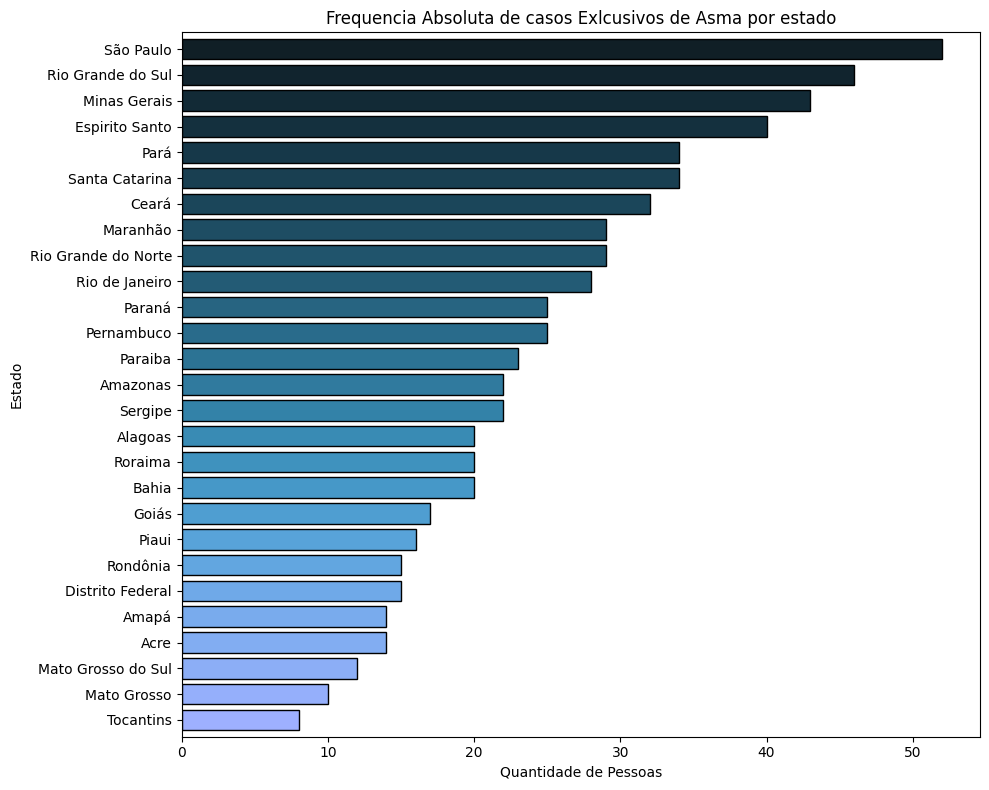

In [75]:
contagem_asma_estado = df_filtrado.loc[mask_asma,'Estado'].value_counts().sort_values()
cor = cm.berlin(np.linspace(0,0.8),27)
contagem_asma_estado.plot(kind='barh',edgecolor='black',figsize=(10,8),width=0.8, color=cor)
plt.title('Frequencia Absoluta de casos Exlcusivos de Asma por estado')
plt.xlabel('Quantidade de Pessoas')
plt.tight_layout()
plt.show()
plt.close()

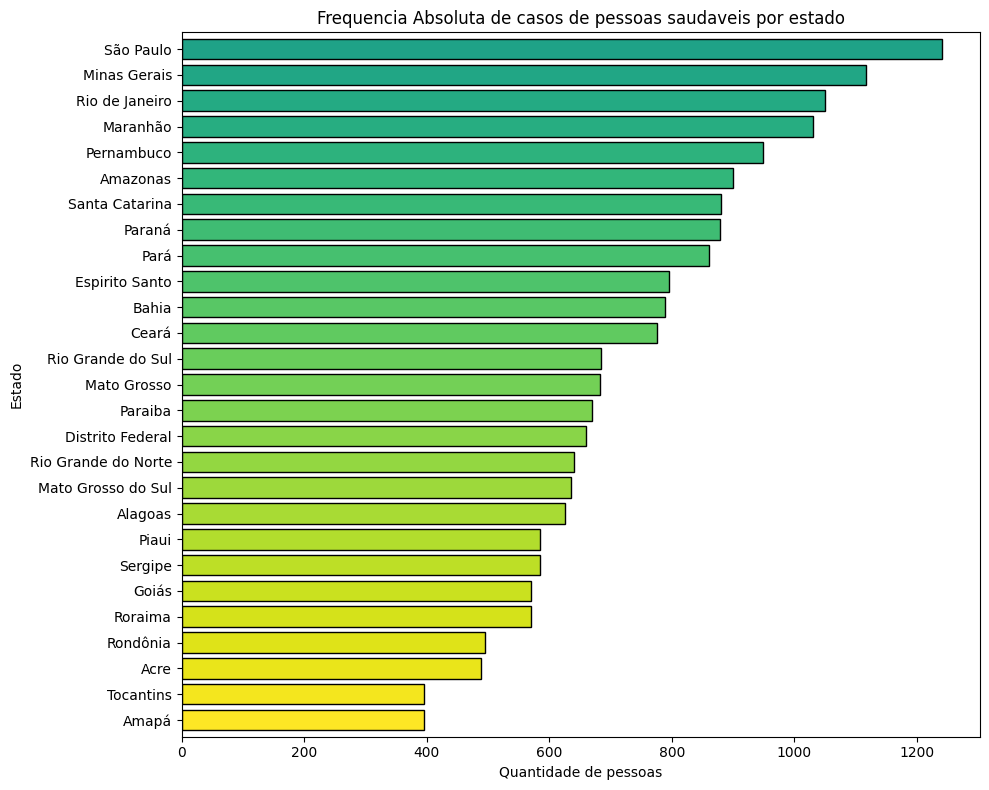

In [77]:
contagem_saudavel_estado = df_filtrado.loc[mask_saudavel,'Estado'].value_counts().sort_values()
cor = cm.viridis_r(np.linspace(0,0.8),27)
contagem_saudavel_estado.plot(kind='barh',color=cor,width=0.8,edgecolor='black',figsize=(10,8))
plt.title('Frequencia Absoluta de casos de pessoas saudaveis por estado')
plt.xlabel('Quantidade de pessoas')
plt.tight_layout()
plt.show()
plt.close()

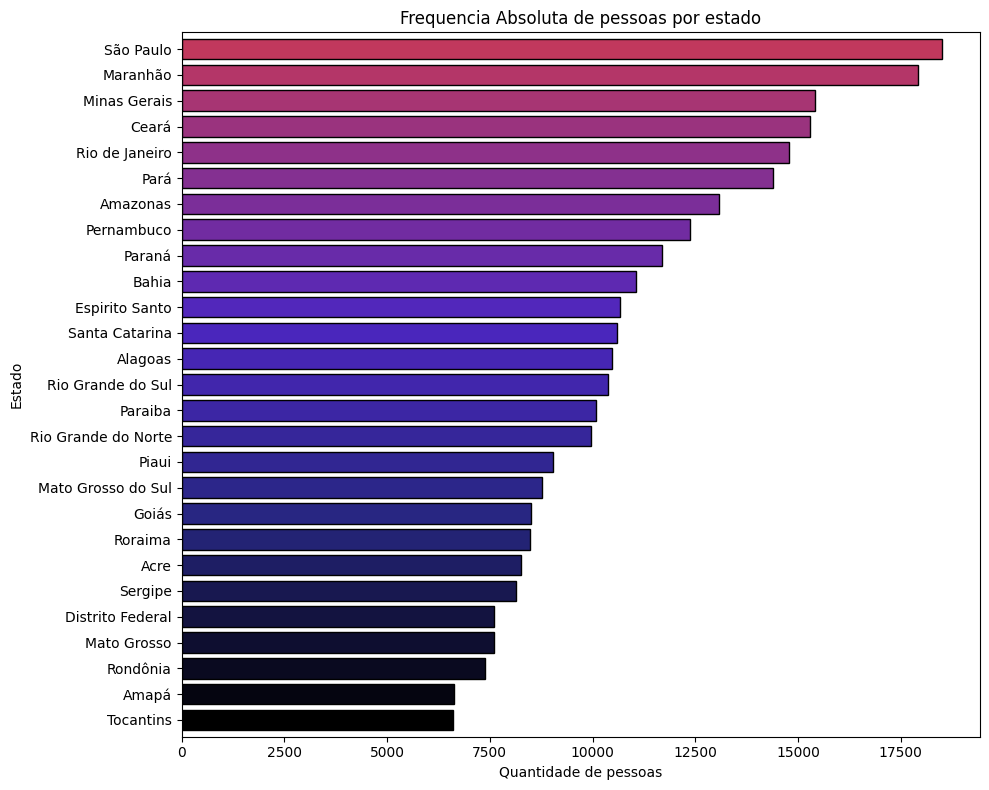

In [78]:
contagem_pessoa_estado = df['Estado'].value_counts().sort_values()
cor = cm.CMRmap(np.linspace(0,0.8),27)
contagem_pessoa_estado.plot(kind='barh',color=cor,width=0.8,edgecolor='black',figsize=(10,8))
plt.title('Frequencia Absoluta de pessoas por estado')
plt.xlabel('Quantidade de pessoas')
plt.tight_layout()
plt.show()
plt.close()